# MNIST Digit Recognition Case Study

This notebook implements a handwritten digit recognition system using the MNIST dataset.

Steps covered:
1. Data Loading
2. Data Preprocessing
3. Model Creation
4. Model Training
5. Model Evaluation
6. Prediction

The goal is to train a neural network that can correctly classify handwritten digits from 0–9.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Data Loading

The MNIST dataset contains 70,000 grayscale images of handwritten digits.

- 60,000 training images
- 10,000 testing images
- Image size: 28 × 28 pixels

In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

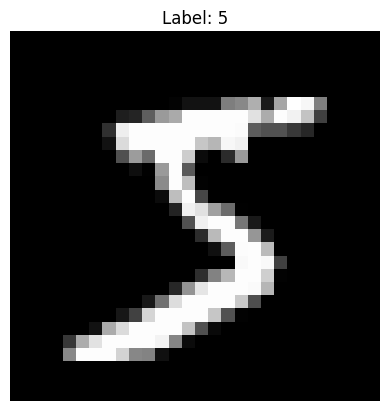

In [7]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')

## Data Preprocessing

Two preprocessing steps are applied:

1. **Normalization**
   - Pixel values range from 0–255.
      - They are scaled to 0–1 by dividing by 255.

      2. **Flattening**
         - Images of size 28×28 are converted into a vector of 784 features.

In [8]:
# normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# flatten images
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

print("New training shape:", x_train.shape)

New training shape: (60000, 784)


## Model Architecture

We use a simple feed-forward neural network.

Layers:
- Dense layer with 128 neurons (ReLU)
- Dense layer with 64 neurons (ReLU)
- Output layer with 10 neurons (Softmax)

The output layer predicts probabilities for digits 0–9.

In [9]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8784 - loss: 0.4241
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9687 - loss: 0.1037
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9779 - loss: 0.0685
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9841 - loss: 0.0488
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9867 - loss: 0.0410


## Model Evaluation

The trained model is evaluated on the test dataset to measure its performance on unseen data.

In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9754 - loss: 0.0883
Test Accuracy: 0.9771999716758728


In [13]:
#prediction example
prediction = model.predict(x_test[0].reshape(1,784))

predicted_digit = np.argmax(prediction)

print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted digit: 7
Actual digit: 7


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

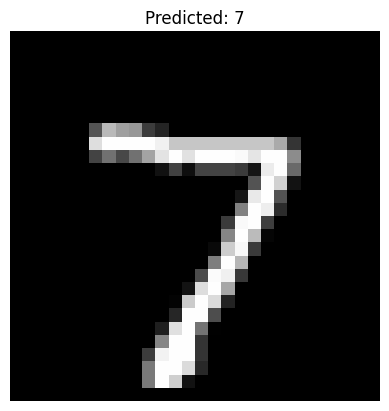

In [14]:
#showing prediction image
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')

## Conclusion

The neural network successfully learns patterns in handwritten digits using the MNIST dataset.

The model achieves approximately 97–98% accuracy on the test dataset, demonstrating effective classification of handwritten digits.

This case study shows how neural networks can be applied to image recognition tasks.